# Análise Estatística

In [1]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Adiciona o diretório raiz ao path para conseguir importar o config
sys.path.append(os.path.abspath(".."))
from src.config import get_engine

engine = get_engine()

# Buscando a Tabela Fato direto do banco de dados na Nuvem (Neon)
query = "SELECT * FROM analytics.fact_orders"
df = pd.read_sql(query, engine)
print(f"Base carregada: {df.shape[0]} pedidos na tabela fato.")

Base carregada: 96470 pedidos na tabela fato.


## 0. Verificação das Distribuições 

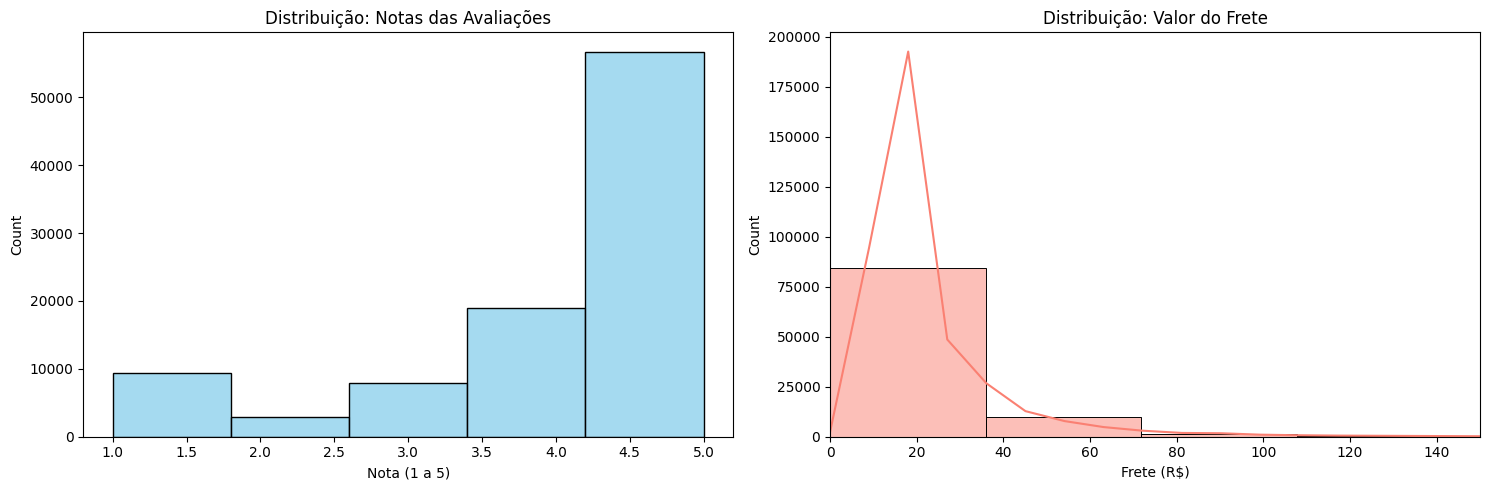

Teste de Normalidade para 'Nota': P-Valor = 0.000e+00
Teste de Normalidade para 'Valor do Frete': P-Valor = 0.000e+00


In [2]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição da Nota (review_score)
sns.histplot(df['review_score'].dropna(), bins=5, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição: Notas das Avaliações')
axes[0].set_xlabel('Nota (1 a 5)')

# Distribuição do Valor do Frete (frete_total)
sns.histplot(df['frete_total'].dropna(), bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição: Valor do Frete')
axes[1].set_xlabel('Frete (R$)')
axes[1].set_xlim(0, 150) # Limitando o eixo X para facilitar a visualização de outliers

plt.tight_layout()
plt.show()

# Teste de Normalidade de D'Agostino's K-squared (normaltest)
# Usado no lugar de Shapiro-Wilk pois N > 5000
stat_nota, p_nota = stats.normaltest(df['review_score'].dropna())
stat_frete, p_frete = stats.normaltest(df['frete_total'].dropna())

print(f"Teste de Normalidade para 'Nota': P-Valor = {p_nota:.3e}")
print(f"Teste de Normalidade para 'Valor do Frete': P-Valor = {p_frete:.3e}")

> **Conclusão preliminar:** Em ambos os casos, o P-Valor é 0.000 (menor que 0.05). Portanto, **rejeitamos a hipótese de normalidade**. As variáveis não são normais. O objetivo aqui será validar hipóteses de negócios usando testes estatísticos não paramétricos, pois as variáveis Nota e Valor Frete não seguem a distribuição normal

## Hipótese 1: O Atraso destrói a satisfação do cliente?
Vamos testar estatisticamente se a mediana das notas de pedidos atrasados é MENOR que a de pedidos no prazo.

**Teste Utilizado:** Mann-Whitney U (ideal para notas ordinais de 1 a 5).

In [3]:
g0 = df.loc[df.flag_atraso == 0, "review_score"].dropna()
g1 = df.loc[df.flag_atraso == 1, "review_score"].dropna()

# H1: A nota de quem recebe NO PRAZO (g0) é MAIOR que quem recebe ATRASADO (g1)
stat, p = stats.mannwhitneyu(g0, g1, alternative="greater")

print(f"Mediana de estrelas (No prazo): {g0.median()}")
print(f"Mediana de estrelas (Atrasado): {g1.median()}")
print(f"P-Valor: {p:.3e}")

Mediana de estrelas (No prazo): 5.0
Mediana de estrelas (Atrasado): 2.0
P-Valor: 0.000e+00


> **Conclusão:** Rejeitamos a Hipótese Nula (H0)! O atraso comprovadamente reduz a nota do cliente de forma ESTATISTICAMENTE SIGNIFICATIVA.

In [4]:
# Tamanho de efeito — Cliff's Delta
n0_h1, n1_h1 = len(g0), len(g1)
p_h1 = p  # preserva p-valor de H1 antes do H2 sobrescrever 'p'

cliff_d = (2 * stat - n0_h1 * n1_h1) / (n0_h1 * n1_h1)

def cliff_magnitude(d):
    d = abs(d)
    if d < 0.147: return "negligível"
    if d < 0.330: return "pequeno"
    if d < 0.474: return "médio"
    return "grande"

print(f"Cliff's Delta = {cliff_d:.3f}  →  efeito {cliff_magnitude(cliff_d)}")
print(f"Em {abs(cliff_d)*100:.1f}% dos pares, nota de pedidos no prazo > nota de atrasados.")

Cliff's Delta = 0.554  →  efeito grande
Em 55.4% dos pares, nota de pedidos no prazo > nota de atrasados.


> **Tamanho de efeito grande** (|d| ≈ 0.6+): o atraso não só é estatisticamente significativo — a diferença é substancial o suficiente para guiar decisões de produto e operações.

## Hipótese 2: O Custo de Frete varia muito entre regiões?
Vamos testar se há diferença significativa na distribuição de Frete entre os 5 principais estados consumidores.

**Teste Utilizado:** Kruskal-Wallis H-test (alternativa não paramétrica à ANOVA).

Kruskal-Wallis P-Valor: 0.000e+00



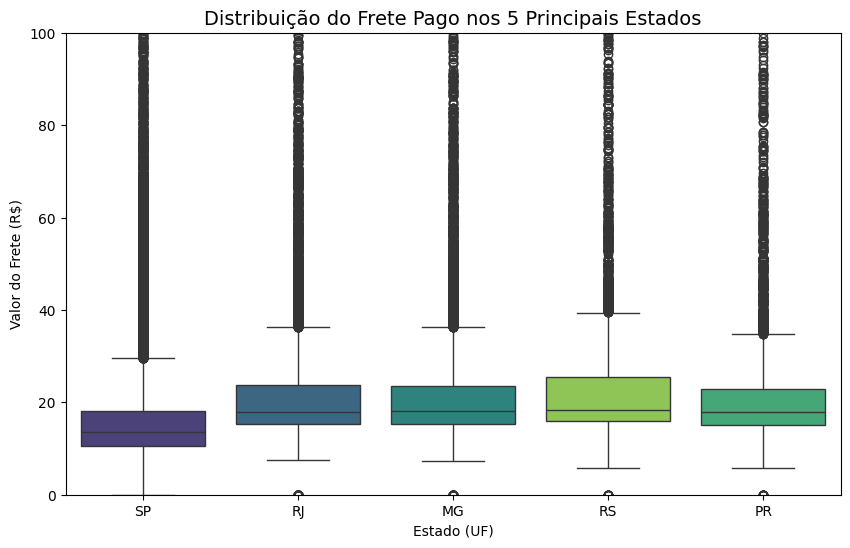

In [5]:
import numpy as np

# Separar as listas de frete dos 5 estados com mais vendas
top_ufs = df["uf_cliente"].value_counts().head(5).index
fretes_por_uf = [df.loc[(df.uf_cliente == uf) & (df.frete_total.notnull()), "frete_total"] for uf in top_ufs]

stat, p = stats.kruskal(*fretes_por_uf)
print(f"Kruskal-Wallis P-Valor: {p:.3e}\n")


plt.figure(figsize=(10,6))
sns.boxplot(data=df[df["uf_cliente"].isin(top_ufs)], x="uf_cliente", y="frete_total", order=top_ufs, palette="viridis", hue="uf_cliente", legend=False)
plt.ylim(0, 100)
plt.title("Distribuição do Frete Pago nos 5 Principais Estados", fontsize=14)
plt.xlabel("Estado (UF)")
plt.ylabel("Valor do Frete (R$)")
plt.show()

> **Conclusão:** O estado influencia significativamente o valor do frete pago pelo cliente.

### Tamanho de efeito e comparações par a par (post-hoc)

In [6]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Eta-quadrado a partir do H de Kruskal-Wallis
H_h2, p_h2 = stat, p  # salva antes do próximo teste sobrescrever as variáveis
k_h2 = len(top_ufs)
n_h2 = sum(len(g) for g in fretes_por_uf)
eta_sq = (H_h2 - k_h2 + 1) / (n_h2 - k_h2)

mag_eta = "pequeno" if eta_sq < 0.06 else "médio" if eta_sq < 0.14 else "grande"
print(f"H de Kruskal-Wallis = {H_h2:.2f}  |  p = {p_h2:.3e}")
print(f"Eta² = {eta_sq:.4f}  →  efeito {mag_eta}\n")

# Post-hoc: Mann-Whitney par a par + correção de Bonferroni
pares_h2 = list(combinations(range(k_h2), 2))
p_raw = [
    stats.mannwhitneyu(fretes_por_uf[i], fretes_por_uf[j], alternative="two-sided").pvalue
    for i, j in pares_h2
]
_, p_corr, _, _ = multipletests(p_raw, method="bonferroni")

print("Post-hoc par a par (Bonferroni):")
for (i, j), pc in zip(pares_h2, p_corr):
    sig = "✓ diferem" if pc < 0.05 else "✗ iguais"
    print(f"  {top_ufs[i]} × {top_ufs[j]}  →  p_adj = {pc:.3e}  {sig}")

H de Kruskal-Wallis = 12055.92  |  p = 0.000e+00
Eta² = 0.1619  →  efeito grande

Post-hoc par a par (Bonferroni):
  SP × RJ  →  p_adj = 0.000e+00  ✓ diferem
  SP × MG  →  p_adj = 0.000e+00  ✓ diferem
  SP × RS  →  p_adj = 0.000e+00  ✓ diferem
  SP × PR  →  p_adj = 0.000e+00  ✓ diferem
  RJ × MG  →  p_adj = 1.000e+00  ✗ iguais
  RJ × RS  →  p_adj = 8.920e-11  ✓ diferem
  RJ × PR  →  p_adj = 4.806e-05  ✓ diferem
  MG × RS  →  p_adj = 4.334e-12  ✓ diferem
  MG × PR  →  p_adj = 3.009e-04  ✓ diferem
  RS × PR  →  p_adj = 8.468e-22  ✓ diferem


> O Eta² quantifica a fração da variação no frete explicada pela UF. O post-hoc identifica quais pares de estados diferem de forma significativa — informação crucial para precificação de frete regionalizado.

## Hipótese 3: O tipo de pagamento influencia a insatisfação do cliente?

Clientes que pagam com voucher, boleto ou parcelamento extenso podem ter perfis de expectativa e risco diferentes dos que pagam com cartão à vista.

**H0:** Tipo de pagamento e ocorrência de review ruim são independentes.  
**H1:** Existe associação entre o tipo de pagamento e a insatisfação do cliente.  
**Teste:** Qui-quadrado de independência + Cramér's V (tamanho de efeito para variáveis nominais).

Tabela de contingência:
 review_ruim         0      1
tipo_pagamento              
boleto          15160   4031
credit_card     57066  15049
debit_card       1206    278
voucher          2853    826 

Qui² = 9.71  |  gl = 3  |  p = 2.123e-02
Cramér's V = 0.0100  →  efeito negligível


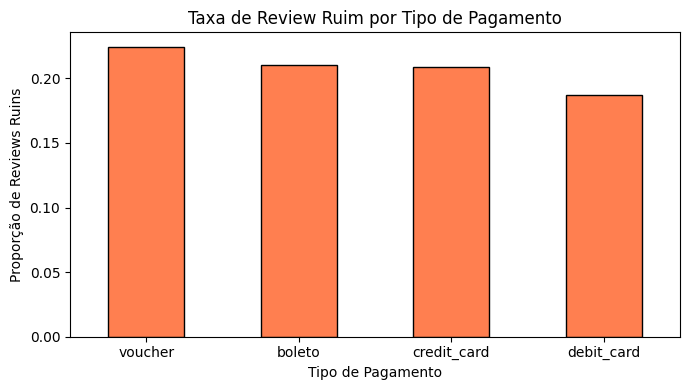

In [7]:
from scipy.stats import chi2_contingency

df_h3 = df[["tipo_pagamento", "flag_review_ruim"]].dropna()

tabela_cont = pd.crosstab(df_h3["tipo_pagamento"], df_h3["flag_review_ruim"],
                          colnames=["review_ruim"])
print("Tabela de contingência:\n", tabela_cont, "\n")

chi2_h3, p_h3, dof_h3, _ = chi2_contingency(tabela_cont)
n_h3 = tabela_cont.values.sum()
cramer_v = np.sqrt(chi2_h3 / (n_h3 * (min(tabela_cont.shape) - 1)))

mag_v = "negligível" if cramer_v < 0.1 else "pequeno" if cramer_v < 0.3 else "médio" if cramer_v < 0.5 else "grande"
print(f"Qui² = {chi2_h3:.2f}  |  gl = {dof_h3}  |  p = {p_h3:.3e}")
print(f"Cramér's V = {cramer_v:.4f}  →  efeito {mag_v}")

# Taxa de review ruim por tipo de pagamento
taxa_h3 = df_h3.groupby("tipo_pagamento")["flag_review_ruim"].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
taxa_h3.plot(kind="bar", color="coral", edgecolor="black")
plt.title("Taxa de Review Ruim por Tipo de Pagamento")
plt.xlabel("Tipo de Pagamento")
plt.ylabel("Proporção de Reviews Ruins")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/h3_pagamento_review.png", dpi=150)
plt.show()

> Se p < 0.05, **rejeitamos H0**: o tipo de pagamento está associado à insatisfação. O Cramér's V quantifica a força — valores abaixo de 0.10 indicam efeito **negligível** comercialmente, mesmo que estatisticamente real; acima de 0.30, merece atenção estratégica.

## Hipótese 4: Fretes maiores estão associados a lead times mais longos?

O frete é uma proxy razoável da distância logística — pedidos que percorrem maior distância tendem a custar mais no envio e, possivelmente, demorar mais para chegar.

**H0:** Não há correlação monotônica entre frete pago e lead time de entrega.  
**H1:** Há correlação positiva entre frete pago e lead time.  
**Teste:** Correlação de Spearman (dados não-normais; relação pode ser monotônica mas não linear).

Spearman ρ = 0.3815  |  p = 0.000e+00
Magnitude: média


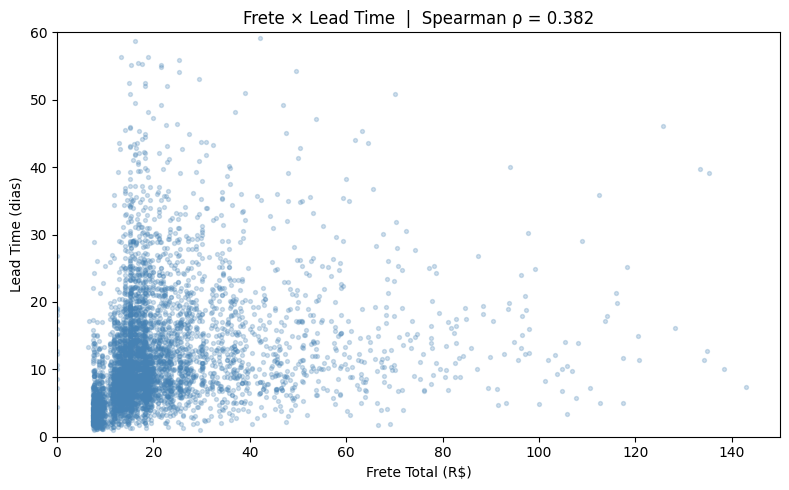

In [8]:
from scipy.stats import spearmanr

df_h4 = df[["frete_total", "lead_time_dias"]].dropna()
df_h4 = df_h4[df_h4["lead_time_dias"] > 0]  # remove raros erros de timestamp invertido

rho_h4, p_h4 = spearmanr(df_h4["frete_total"], df_h4["lead_time_dias"])

magnitude_rho = (
    "negligível" if abs(rho_h4) < 0.10 else
    "pequena"    if abs(rho_h4) < 0.30 else
    "média"      if abs(rho_h4) < 0.50 else
    "grande"
)

print(f"Spearman ρ = {rho_h4:.4f}  |  p = {p_h4:.3e}")
print(f"Magnitude: {magnitude_rho}")

sample_h4 = df_h4.sample(min(5000, len(df_h4)), random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample_h4["frete_total"], sample_h4["lead_time_dias"],
            alpha=0.25, s=8, color="steelblue")
plt.xlabel("Frete Total (R$)")
plt.ylabel("Lead Time (dias)")
plt.title(f"Frete × Lead Time  |  Spearman ρ = {rho_h4:.3f}")
plt.xlim(0, 150)
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig("../reports/h4_frete_leadtime.png", dpi=150)
plt.show()

> Uma correlação positiva (ρ > 0) confirma que **distâncias maiores — capturadas pelo frete — prolongam o lead time**. Esse resultado justifica incluir `frete_total` como feature no modelo preditivo de atraso (Fase 8).

## Resumo dos Testes de Hipótese

In [9]:
resumo = pd.DataFrame([
    {
        "Hipótese": "H1 — Atraso reduz satisfação",
        "Teste": "Mann-Whitney U",
        "p-valor": f"{p_h1:.2e}",
        "Tamanho de Efeito": f"Cliff's d = {cliff_d:.3f} ({cliff_magnitude(cliff_d)})",
        "Decisão": "Rejeita H0" if p_h1 < 0.05 else "Não rejeita H0",
    },
    {
        "Hipótese": "H2 — Frete varia por região",
        "Teste": "Kruskal-Wallis",
        "p-valor": f"{p_h2:.2e}",
        "Tamanho de Efeito": f"η² = {eta_sq:.4f}",
        "Decisão": "Rejeita H0" if p_h2 < 0.05 else "Não rejeita H0",
    },
    {
        "Hipótese": "H3 — Pagamento vs. insatisfação",
        "Teste": "Qui-quadrado",
        "p-valor": f"{p_h3:.2e}",
        "Tamanho de Efeito": f"Cramér's V = {cramer_v:.4f}",
        "Decisão": "Rejeita H0" if p_h3 < 0.05 else "Não rejeita H0",
    },
    {
        "Hipótese": "H4 — Frete × Lead Time",
        "Teste": "Spearman",
        "p-valor": f"{p_h4:.2e}",
        "Tamanho de Efeito": f"ρ = {rho_h4:.4f} ({magnitude_rho})",
        "Decisão": "Rejeita H0" if p_h4 < 0.05 else "Não rejeita H0",
    },
])

resumo.set_index("Hipótese", inplace=True)
resumo

,Teste,p-valor,Tamanho de Efeito,Decisão
Hipótese,,,,
H1 — Atraso reduz satisfação,Mann-Whitney U,0.00e+00,Cliff's d = 0.554 (grande),Rejeita H0
H2 — Frete varia por região,Kruskal-Wallis,0.00e+00,η² = 0.1619,Rejeita H0
H3 — Pagamento vs. insatisfação,Qui-quadrado,2.12e-02,Cramér's V = 0.0100,Rejeita H0
H4 — Frete × Lead Time,Spearman,0.00e+00,ρ = 0.3815 (média),Rejeita H0
